In [2]:
!pwd

/users/khordadi/truejit/evaluation/compilation-plan


In [3]:
import os
import sys
from pathlib import Path
from solver import *
from profiling import *
import numpy as np

In [4]:
benchmark = ffmpeg

In [5]:
generate_static_info(benchmark.binary)

In [6]:
static_info = get_static_info(benchmark.binary)
static_info

,id,name,size.bytecode,size.static
0,24,__wasm_call_ctors,8,864
1,25,undefined_weak:__wasilibc_find_relpath_alloc,4,504
2,26,_start,69,984
3,27,__SIG_IGN,3,512
4,28,__SIG_ERR,5,504
...,...,...,...,...
27485,27509,ff_tx_fft16_ns_int32_c,2188,3344
27486,27510,ff_tx_fft8_ns_int32_c,1144,2096
27487,27511,ff_tx_fft4_ns_int32_c,382,912
27488,27512,ff_tx_fft2_ns_int32_c,163,664


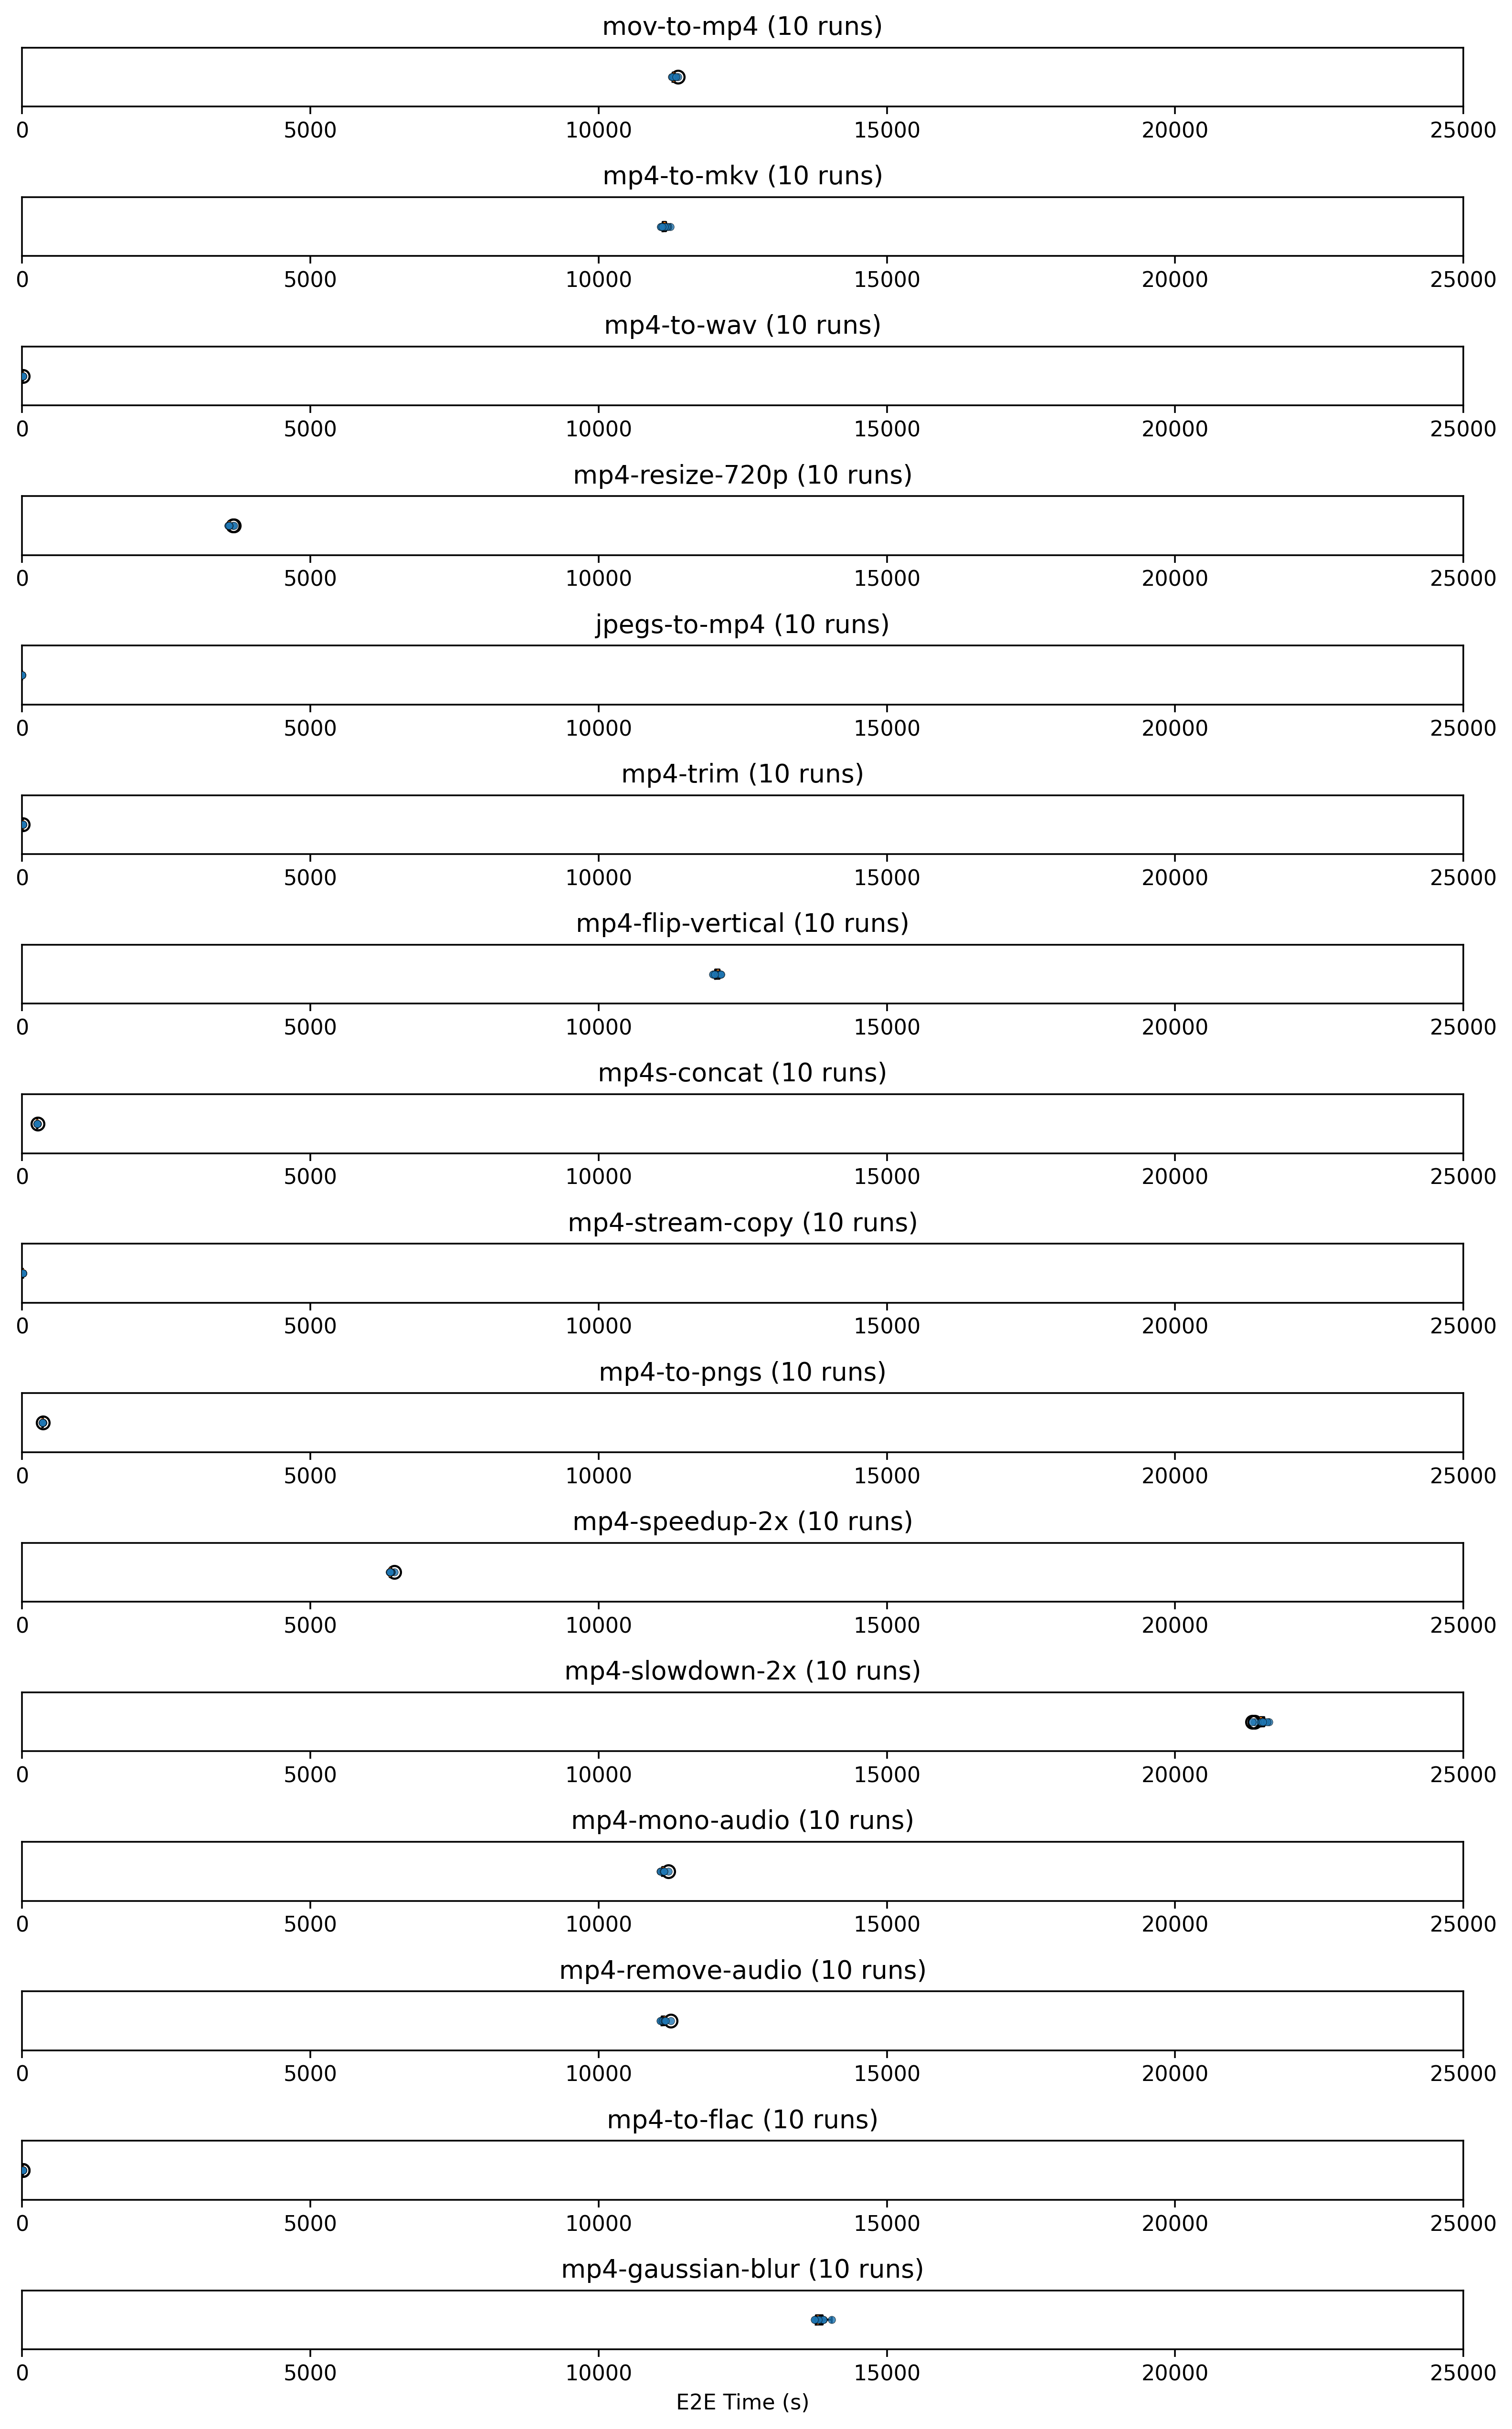

In [29]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(len(benchmark.workloads), 1, figsize=(10, 1 * len(benchmark.workloads)), dpi=320)

for idx, workload in enumerate(benchmark.workloads):
    profile = Profile(profiles_root(benchmark.binary, workload.name, 'interp'))
    data = profile.e2e
    data = np.array(data, dtype=float) / 1e9

    axes[idx].boxplot(data, vert=False)
    axes[idx].scatter(data, np.zeros_like(data) + 1, s=12, alpha=0.8, color='tab:blue', edgecolors='black', linewidths=0.2, zorder=3)
    
    axes[idx].set_title(f'{workload.name} ({len(data)} runs)')
    axes[idx].set_xlim(0, 25000)
    # axes[idx].grid(axis='x')
    # no y ticks
    axes[idx].set_yticks([])

# axes[idx].legend()
axes[idx].set_xlabel('E2E Time (s)')

plt.tight_layout()
plt.show()


In [ ]:
generate_profile_oracle(benchmark)
generate_profile_union(benchmark)
generate_plans(benchmark)

In [7]:
base_profile = pd.read_csv(profiles_root(benchmark.binary, benchmark.workloads[0].name) / 'profile.csv')
base_profile

,id,name,size.bytecode,size.static,start.jit,exec.jit,freq.jit,compilation.jit,size.dynamic.jit,start.interp,exec.interp,freq.interp,exec.spec,compilation.spec,size.dynamic.spec
0,26,_start,69,984,70848,0,0,3675552,984,72965,0,0,999999999999,999999999999,999999999999
1,24,__wasm_call_ctors,8,864,3747522,0,1,1823296,864,77094,0,1,999999999999,999999999999,999999999999
2,30,init,20,840,5571401,0,1,1978378,840,77805,0,1,999999999999,999999999999,999999999999
3,1540,__wasi_clock_time_get,20,824,7550469,0,109,1956529,824,79312,0,109,999999999999,999999999999,999999999999
4,1588,__wasilibc_populate_preopens,182,1296,9513100,0,1,5488068,1296,87298,0,1,999999999999,999999999999,999999999999
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2455,2384,dummy,3,512,114039339266,0,1,1467188,512,11307168754840,0,1,999999999999,999999999999,999999999999
2456,1597,__wasm_call_dtors,15,864,114040809792,1000000,1,1879842,864,11307168757371,0,1,999999999999,999999999999,999999999999
2457,1596,dummy,3,512,114042691897,0,1,1449014,512,11307168758076,0,1,999999999999,999999999999,999999999999
2458,1715,__stdio_exit,389,1712,114044142365,0,1,8313526,1712,11307168758729,0,1,999999999999,999999999999,999999999999


In [8]:
plan = plan_json_to_df(plans_root(benchmark.binary, benchmark.workloads[0].name, 'min_e2e.unconstrained.default_static') / 'oracle.json')
plan

,id,mode
0,1512,interpret
1,10011,interpret
2,10225,interpret
3,27106,interpret
4,4167,interpret
...,...,...
27485,27509,static
27486,27510,static
27487,27511,static
27488,27512,static


In [9]:
pe = PlanEvaluation(static_info, base_profile, plan)
pe.e2e

74646000000.0

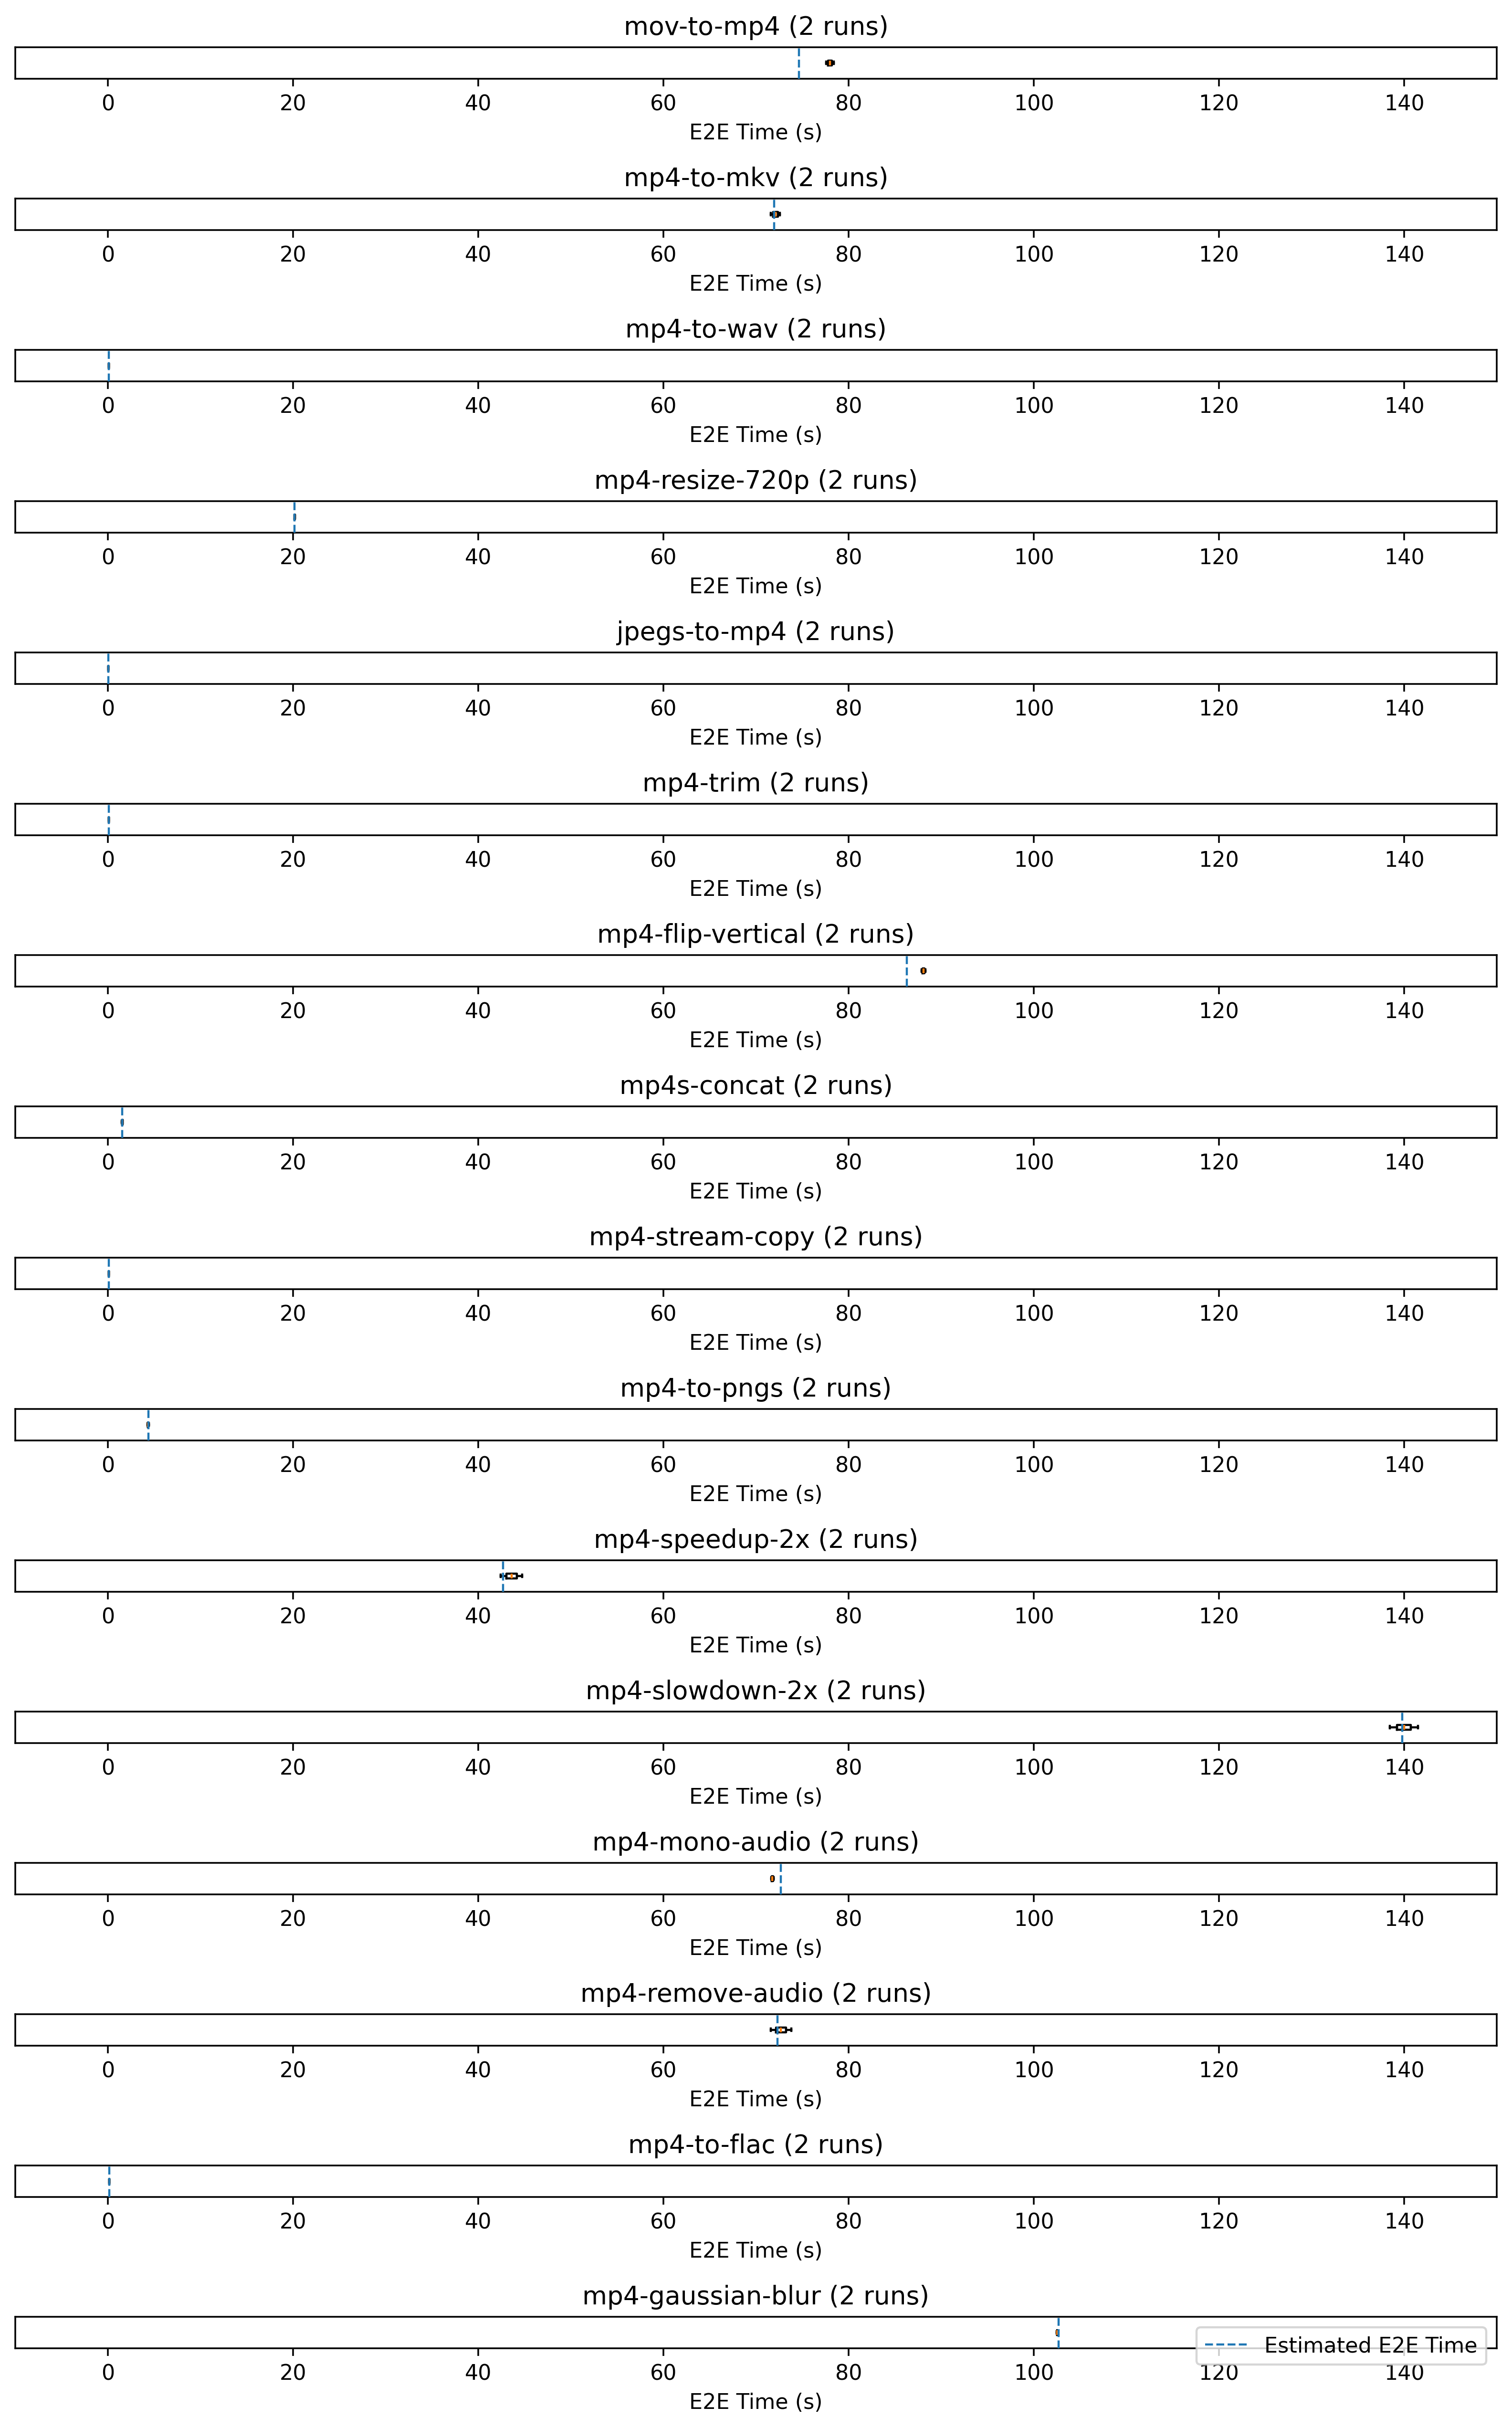

In [22]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(len(benchmark.workloads), 1, figsize=(10, 1 * len(benchmark.workloads)), dpi=320)

for idx, wl in enumerate(benchmark.workloads):
    base_profile = pd.read_csv(profiles_root(benchmark.binary, wl.name) / 'profile.csv')
    plan = plan_json_to_df(plans_root(benchmark.binary, wl.name, 'min_e2e.unconstrained.default_static') / 'oracle.json')
    pe = PlanEvaluation(static_info, base_profile, plan)
    estimation = pe.e2e
    
    actual_profile = Profile(profiles_root(benchmark.binary, wl.name, 'min_e2e.unconstrained.default_static/oracle'))
    actuals = actual_profile.e2e

    # make them in s (it's ns now)
    actuals = [x / 1e9 for x in actuals]
    estimation = estimation / 1e9

    # plot on the corresponding subplot
    axes[idx].boxplot(actuals, vert=False)
    axes[idx].axvline(estimation, color='tab:blue', linestyle='--', linewidth=1, label='Estimated E2E Time', zorder=3)   
    axes[idx].set_xlabel('E2E Time (s)')
    axes[idx].set_title(f'{wl.name} ({len(actuals)} runs)')
    axes[idx].set_xlim(-10, 150)

    # remove y-axis ticks and labels
    axes[idx].set_yticks([])
    # axes[idx].grid(axis='x')
axes[idx].legend()

plt.tight_layout()
plt.show()
